In [1]:
!pip install opencv-python-headless


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


# Thresholding Segmentation

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


In [3]:
# Load an image as grayscale
image = cv2.imread('car_green_screen.jpg',0)


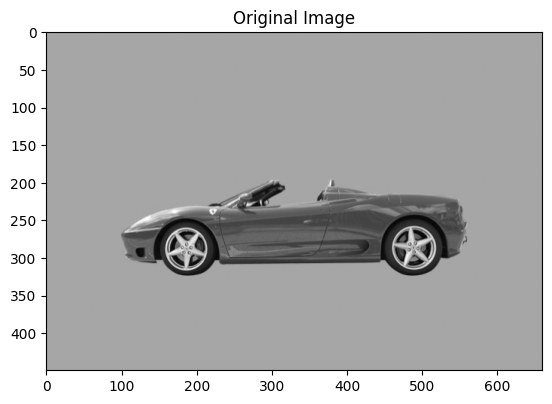

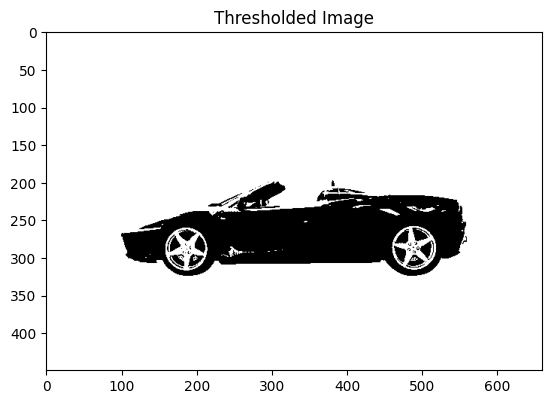

In [4]:

# Apply global thresholding
_, thresholded_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.show()
plt.imshow(thresholded_image, cmap='gray')
plt.title('Thresholded Image')
plt.show()

# Image Segmentation Using K-Means Clustering Using OpenCV

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Load an image
image = cv2.imread('car_green_screen.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [7]:
# Reshape the image to a 2D array of pixels
# and convert to float
pixel_values = image.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

In [8]:
# Define criteria, number of clusters (K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            100,
            0.2)
k = 3 # Number of clusters
_, labels, centers = cv2.kmeans(pixel_values,
                                k,
                                None,
                                criteria,
                                10,
                                cv2.KMEANS_RANDOM_CENTERS)

In [9]:
# Assign new colors to each cluster center
colors = [[255, 0, 0], [0, 255, 0], [0, 0, 255]]
segmented_image = np.zeros((pixel_values.shape [0], 3),
                           dtype=np.uint8)
for i, label in enumerate(np.unique(labels)):
    segmented_image [labels.flatten() == label] = colors[i]

In [10]:
# Reshape back to the original image dimension
segmented_image = segmented_image.reshape(image.shape)

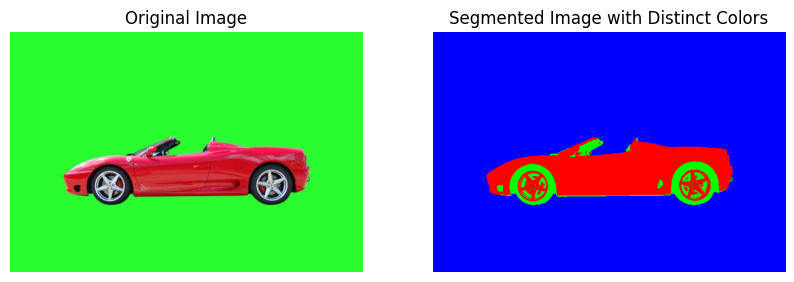

In [11]:
# Show the original and segmented images side by side
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].imshow(image)
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(segmented_image)
axs[1].set_title('Segmented Image with Distinct Colors')
axs[1].axis('off')
plt.show()

# Canny Edge Detection Algorithm

In [12]:
import cv2
import matplotlib.pyplot as plt

In [13]:
# Load an image
img = cv2.imread('car_green_screen.jpg')

In [14]:
# Transform the image into a grayscale format
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [15]:
# Implement the Canny edge detection technique
edges=cv2.Canny(gray, 100, 200)

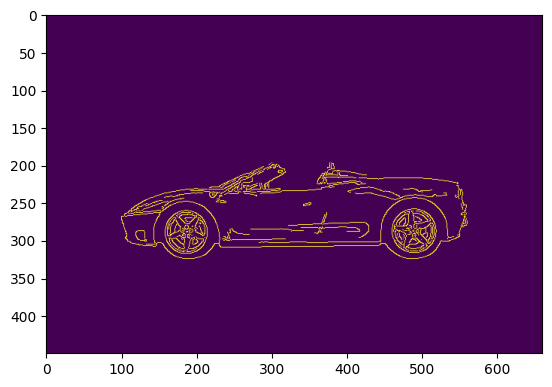

In [16]:
# Plot the processed image
plt.imshow(edges)
# cv2.waitKey(0)

# Deep Learning-Based Segmentation


In [17]:
import torch
from torchvision import models
from torchvision.transforms import functional as F
from PIL import Image

In [18]:
# Load a pre−trained model(e.g., FCN with ResNet backbone)
model = models.segmentation.fcn_resnet101(pretrained=True)
model.eval()

/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [19]:
# Load an image and transform it
image = Image.open('car_green_screen.jpg').convert('RGB')
input_image = F.to_tensor(image)
input_image = F.normalize(input_image,
mean = [0.485, 0.456, 0.406],
std = [0.229, 0.224, 0.225])
input_image = input_image.unsqueeze(0)
with torch.no_grad():
    output = model(input_image)['out'][0]
    output_predictions = output.argmax(0)

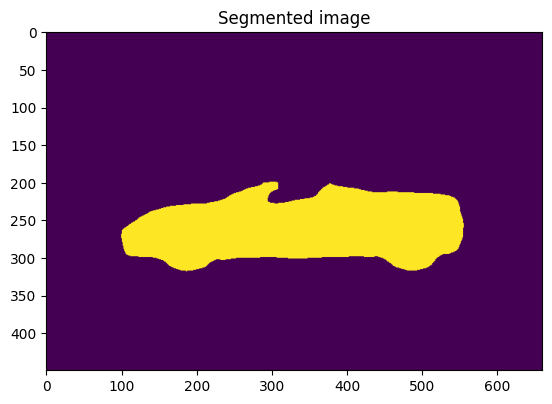

In [20]:
# Display the segmentation output
plt.imshow(output_predictions.numpy())
plt.title('Segmented image')
plt.show()

# FCN Implementation for Semantic Segmentation Using TensorFlow

In [21]:
import tensorflow as tf
from tensorflow.keras.layers import(Conv2D,
Conv2DTranspose,
MaxPooling2D)

2025-11-18 21:23:59.850520: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 21:24:22.983069: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 21:24:34.779281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [22]:
def create_fcn(input_shape=(256, 256, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    # Encoder
    x = Conv2D(32,
               3,
               activation='relu',
               padding='same')(inputs)
    
    x = MaxPooling2D(2)(x)
    x = Conv2D(64,
               3,
               activation='relu',
               padding='same')(x)
    
    x = MaxPooling2D(2)(x)
    x = Conv2D(128,
               3,
               activation='relu',
               padding='same')(x)
    
    x = MaxPooling2D(2)(x)
    
    # Decoder
    x = Conv2DTranspose(128,
                        3,
                        activation='relu',
                        padding='same')(x)
    
    x = Conv2DTranspose(64,
                        3,
                        activation='relu',
                        padding='same')(x)
    
    x = Conv2DTranspose(32,
                        3,
                        activation='relu',
                        padding='same')(x)
    
    x = Conv2D(3,
               1,
               activation='softmax',
               padding='same')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=x)

In [23]:
model = create_fcn()
model.summary()

2025-11-18 21:24:43.218201: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,187 (1.27 MB)

 Trainable params: 333,187 (1.27 MB)

 Non-trainable params: 0 (0.00 B)